In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

In [6]:
# ================= 训练专用代码（本演示不需要，已注释掉） =================
# 以下代码只在「用本地数据微调 Faster R-CNN」时才需要：
#   - 安装 pycocotools（COCO 评估指标用）
#   - 克隆 torchvision 的 references/detection 参考代码（engine.py、coco_utils.py 等）
# 本次仅做预训练模型推理演示，因此跳过，避免每次运行都联网 git clone。
# 以后如需微调，取消注释即可。
#
# import os
# import shutil
# import subprocess
# import sys
# import tempfile
# try:
#     import pycocotools  # noqa: F401
# except ImportError:
#     try:
#         from IPython import get_ipython
#         ipython = get_ipython()
#         if ipython is not None:
#             ipython.run_line_magic("pip", "install", "-q", "pycocotools")
#         else:
#             subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycocotools"])
#     except Exception:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycocotools"])
#
# vision_dir = os.path.join(tempfile.gettempdir(), "vision")
# if not os.path.exists(vision_dir):
#     subprocess.check_call(
#         ["git", "clone", "--depth", "1",
#          "https://github.com/pytorch/vision.git", vision_dir],
#         stdout=subprocess.DEVNULL,
#         stderr=subprocess.STDOUT,
#     )
#
# for name in ["utils.py", "transforms.py", "coco_eval.py", "engine.py", "coco_utils.py"]:
#     src = os.path.join(vision_dir, "references", "detection", name)
#     if os.path.exists(src):
#         shutil.copy(src, ".")
#     else:
#         raise FileNotFoundError(f"Missing reference file: {src}")

In [7]:
# 加载模型：使用 MS COCO 数据集预训练的 Faster R-CNN（ResNet50-FPN 主干）。
# 关键修改：原代码把分类头替换成 21 类（VOC），再加载 faster_rcnn_state.pth，
# 但本机没有该权重文件，会直接报错。现在【不再替换分类头】，直接使用完整的
# COCO 预训练模型（91 类：背景 + 90 个物体类别），开箱即可用于推理。
weights = FasterRCNN_ResNet50_FPN_Weights.COCO_V1
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# COCO 类别名列表，下标即 label（0 为背景，1~90 为物体类别），供画图时使用
CLASSES = weights.meta['categories']
print(f"模型已加载，COCO 类别总数（含背景）: {len(CLASSES)}")

# ========== 训练专用代码（已注释掉） ==========
# 以下代码仅用于「用本地数据微调 Faster R-CNN」，本次推理演示不需要。
# num_classes = 21
# in_features = model.roi_heads.box_predictor.cls_score.in_features
# model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = torch.optim.SGD(params, lr=0.001, weight_decay=0.0005)
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

模型已加载，COCO 类别总数（含背景）: 91


In [8]:
# 原代码这里加载本地微调权重 faster_rcnn_state.pth，但本机没有该文件，会抛
# FileNotFoundError。现在已不再需要：上面的 Cell 直接使用了 MS COCO 预训练权重，
# 模型加载完成后即可用于推理。
print("已使用 COCO 预训练权重，无需加载 faster_rcnn_state.pth")

已使用 COCO 预训练权重，无需加载 faster_rcnn_state.pth


接着，编写模型测试的代码。

In [9]:
# 对模型进行测试：输入图片路径，返回检测类别索引、包围框、置信度与图像数据
def obj_detector(img_path, detection_threshold=0.70):
    # 读取并预处理图像
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img /= 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # (1, C, H, W)

    model.eval()
    with torch.no_grad():
        output = model(img.to(device))

    pred = output[0]
    boxes = pred['boxes'].data.cpu().numpy()    # (N, 4) -> (x1, y1, x2, y2)
    scores = pred['scores'].data.cpu().numpy()  # (N,)
    labels = pred['labels'].data.cpu().numpy()  # (N,) -> COCO label 索引

    keep = scores >= detection_threshold
    names = labels[keep].tolist()
    boxes = boxes[keep].astype(np.int32)
    scores = scores[keep]

    sample = img[0].permute(1, 2, 0).cpu().numpy()       # (H, W, 3)
    sample = (sample * 255.0).astype(np.uint8)           # 转为 0~255 的 uint8，OpenCV 画框/写文字需要
    return names, boxes, scores, sample

共选取 4 张图片进行测试：
 - airplanes\image_0001.jpg
 - Motorbikes\image_0001.jpg
 - Faces\image_0001.jpg
 - car_side\image_0001.jpg


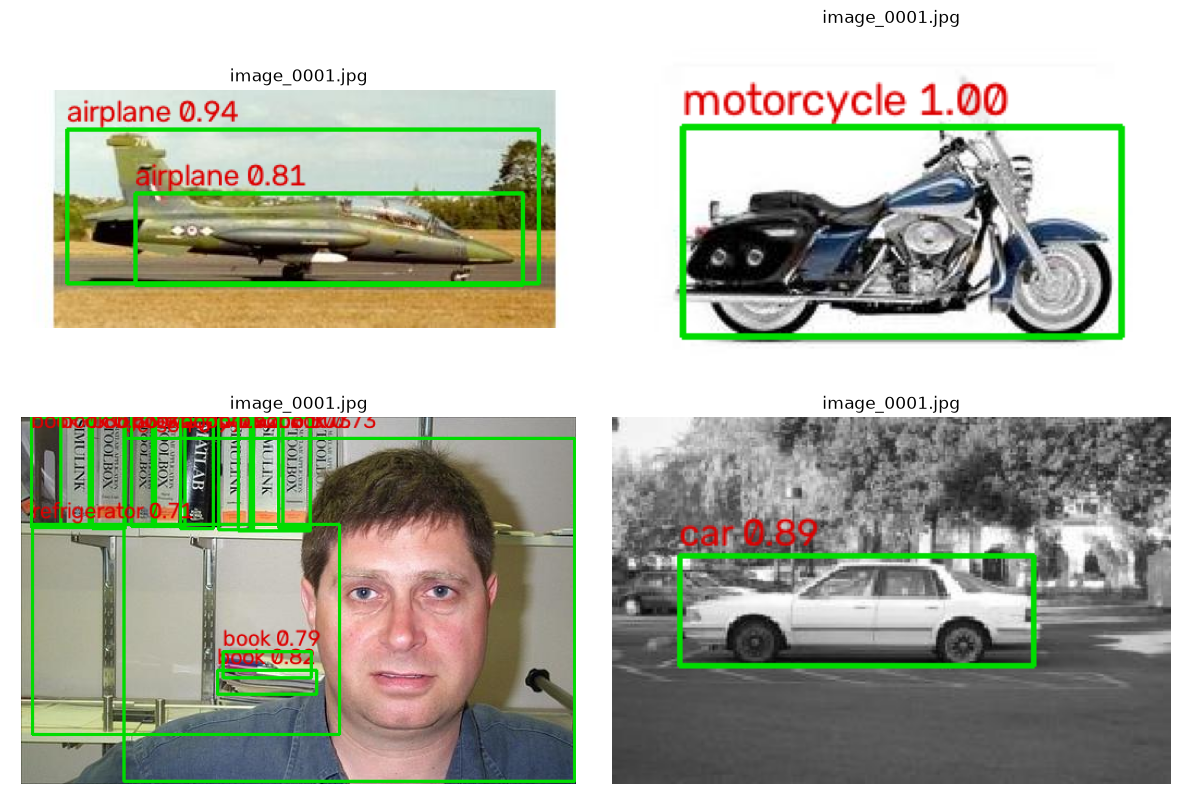

In [10]:
# 在本地 caltech-101 数据集上测试模型的效果
# 本地数据目录（相对本 notebook 也可写作 ../../DataSet/Figure/caltech-101/101_ObjectCategories）
DATA_DIR = r"C:\Users\17934\Desktop\Artificial-Intelligence\3-Resources\Codes\DataSet\Figure\caltech-101\101_ObjectCategories"

# 挑选与 COCO 可检测类别重合度较高的几个类别，每个类别取第一张图做演示
categories = ['airplanes', 'Motorbikes', 'Faces', 'car_side']
img_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff')

pred_files = []
for cat in categories:
    cat_dir = os.path.join(DATA_DIR, cat)
    imgs = sorted(f for f in os.listdir(cat_dir) if f.lower().endswith(img_exts))
    if imgs:
        pred_files.append(os.path.join(cat_dir, imgs[0]))

print(f"共选取 {len(pred_files)} 张图片进行测试：")
for p in pred_files:
    print(" -", os.path.relpath(p, DATA_DIR))

# 可视化检测结果（类别名使用模型加载 Cell 中的 COCO CLASSES）
n = len(pred_files)
cols = 2
rows = (n + cols - 1) // cols
plt.figure(figsize=(6 * cols, 4 * rows))

for i, img_path in enumerate(pred_files):
    names, boxes, scores, sample = obj_detector(img_path)

    plt.subplot(rows, cols, i + 1)
    for j, box in enumerate(boxes):
        # 绘制包围盒与类别名
        cv2.rectangle(sample, (box[0], box[1]), (box[2], box[3]), (0, 220, 0), 2)
        label_text = f"{CLASSES[names[j]]} {scores[j]:.2f}"
        cv2.putText(sample, label_text, (box[0], max(box[1] - 5, 10)),
                    cv2.FONT_HERSHEY_COMPLEX, 0.7, (220, 0, 0), 1, cv2.LINE_AA)

    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.imshow(sample)

plt.tight_layout()
plt.show()